# Machine Learning Fundamentals

# Week 2 – Task 2

# House Price Prediction Using Linear Regression

**Prepared By:** Abdul Raheem

**Course:** Machine Learning Fundamentals

**Organization:** Neurofive Solutions

**Dataset:** California Housing Dataset (Scikit-learn)

---

## Problem Type

Regression

Unlike classification problems that predict categories, regression predicts continuous numerical values.

The objective of this task is to build a Linear Regression model capable of predicting median house prices using selected housing characteristics.

# Objectives

This notebook aims to:

- Load a real-world housing dataset.
- Explore the dataset.
- Select the most relevant features.
- Split the dataset into training and testing subsets.
- Train a Linear Regression model.
- Predict house prices.
- Evaluate the model using RMSE and R² Score.
- Visualize Actual vs Predicted Prices.
- Interpret the model performance in simple language.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Importing the Dataset

The California Housing Dataset is provided by Scikit-learn.

It contains information collected from the California census and is widely used to learn regression techniques.

Each record represents a district and contains several housing-related features along with the median house value.

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

# Preview of Dataset

Before training a Machine Learning model, it is important to inspect the dataset to understand its structure and contents.

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# Dataset Summary

The dataset consists of several numerical housing features.

The target variable is **MedHouseVal**, which represents the median house value for each district.

The dataset contains no missing values, making it suitable for immediate model training.

# Feature Selection

For this task, five important features are selected based on their expected influence on house prices.

Selected Features:

- MedInc (Median Income)
- HouseAge (Average House Age)
- AveRooms (Average Number of Rooms)
- AveOccup (Average Occupancy)
- Latitude (Location)

In [6]:
features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveOccup",
    "Latitude"
]

X = df[features]

y = df["MedHouseVal"]

# Splitting the Dataset

The dataset is divided into two parts:

- Training Set (80%)
- Testing Set (20%)

The training set is used to train the model, while the testing set evaluates how well the model performs on unseen data.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

Training Samples : 16512
Testing Samples : 4128


# Building the Linear Regression Model

Linear Regression is one of the simplest supervised Machine Learning algorithms.

It establishes a relationship between input features and a continuous target variable by fitting the best possible straight line through the data.

In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.44, 0.02,-0.02,-0. ,-0.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['MedInc','HouseAge','AveRooms','AveOccup','Latitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.621
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


# Making Predictions

The trained model is now used to predict house prices for the testing dataset.

In [10]:
y_pred = model.predict(X_test)

In [11]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
20046,0.47700,1.050383
3024,0.45800,1.536313
15663,5.00001,2.236133
20484,2.18600,2.733562
9814,2.78000,2.052495
13311,1.58700,2.230999
7113,1.98200,2.787868
7668,1.57500,2.233799
18246,3.40000,2.018245
5723,4.46600,4.244371


# Model Evaluation

The performance of the Linear Regression model is evaluated using:

- Root Mean Squared Error (RMSE)
- R² Score

RMSE measures the average prediction error, while R² indicates how well the model explains the variation in house prices.

In [12]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("RMSE :", rmse)

print("R² Score :", r2)

RMSE : 0.8049810972472424
R² Score : 0.5055020396798212


# Actual vs Predicted Prices

A scatter plot is used to compare actual house prices with the values predicted by the model.

If the model performs well, the points should appear close to an imaginary diagonal line.

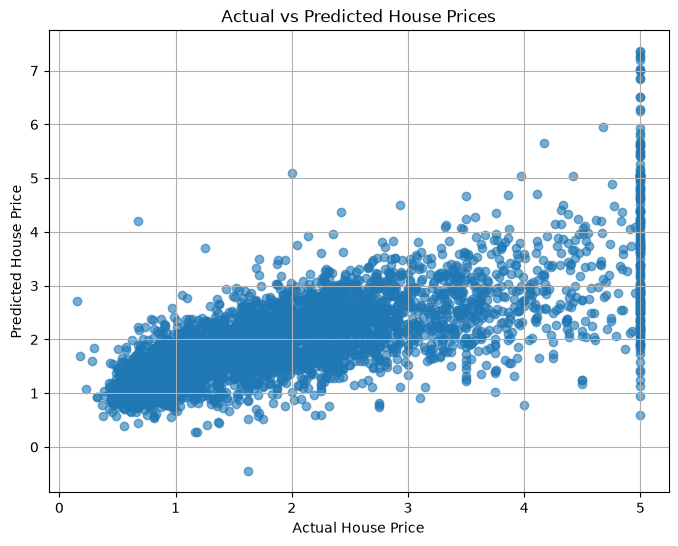

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

# What Does the R² Score Mean?

The R² score tells us how well the model can explain differences in house prices.

For example, if the model achieves an R² score of **0.80**, it means that about **80% of the changes in house prices** can be explained by the features used in the model. The remaining **20%** is influenced by other factors that were not included, such as neighborhood quality, nearby facilities, or market conditions.

In simple terms, a higher R² score means the model's predictions are generally closer to the actual house prices.

# Conclusion

A Linear Regression model was successfully developed to predict house prices using the California Housing Dataset.

Five important housing features were selected for training the model. The model was evaluated using RMSE and R² Score, while a scatter plot visually compared actual and predicted prices.

This task demonstrates the complete workflow of a regression problem, from data preparation to model evaluation, and provides a strong foundation for more advanced regression techniques in future Machine Learning projects.